# Armenian pretraining: crops, GT, and Calamari predictions

**Start with the presentation catalog** (next markdown + code cell). That is the slide deck: every original GT error, with the crop and **original GT vs cleaned GT**. Those problems are resolved in the manifests. Retrain is still required so the codec drops Latin leftovers.

Later sections are working notes from the cleanup. Many still say “problem” even after the label was fixed; trust the catalog for before/after.

Two failure modes we found:

1. **The GT string was wrong** (Latin letters, dummy `z`/`c`, editorial `[brackets]` the page does not show).
2. **The GT named a letter, but the crop was not that letter** (UCLA 0011 gutter boxes). Four of those were dropped.

**Left on purpose** (ink really is that): Dulaurier `~` (աշխարհ ideogram), commas, `"`, Western page numbers, short real words, remaining UCLA/P331 margin numerals.


In [24]:
from __future__ import annotations

import sys
from html import escape
from pathlib import Path

import torch
from IPython.display import HTML, Image as IPyImage, display
from PIL import Image as PILImage


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("Could not locate the greek-ocr repo root.")


REPO = find_repo_root(Path.cwd())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.inference.calamari import _load_image
from src.metrics.metrics import edit_distance
from src.models.calamari.checkpoint import load_calamari_checkpoint
from src.models.calamari.codec import CharacterCodec

DATA = REPO / "data" / "processed" / "armenian" / "pretraining"
IMAGE_DIR = DATA / "image"
CHECKPOINT = (
    REPO
    / "checkpoints"
    / "calamari"
    / "pretrained"
    / "on_armenian"
    / "lstm_layers_3"
    / "final"
    / "best.pt"
)

device = torch.device("cpu")
model, metadata = load_calamari_checkpoint(CHECKPOINT)
model = model.to(device).eval()
codec = CharacterCodec(metadata.charset)

print(f"Repo:        {REPO}")
print(f"Checkpoint:  {CHECKPOINT}")
print(f"Line height: {metadata.line_height}")
print(f"Charset:     {codec.classes} classes")
print("Latin in charset:", [c for c in codec.charset if c.isascii() and c.isalpha()])

Repo:        /home/ra48vol/greek-ocr
Checkpoint:  /home/ra48vol/greek-ocr/checkpoints/calamari/pretrained/on_armenian/lstm_layers_3/final/best.pt
Line height: 48
Charset:     105 classes
Latin in charset: ['c', 'h', 'z']


In [25]:
ARMENIAN = REPO / "data" / "processed" / "armenian"


def lookup_gt(image_name: str) -> tuple[str, str, Path]:
    for partition in ("pretraining", "finetuning"):
        data = ARMENIAN / partition
        for split in ("train", "val", "test"):
            gt_path = data / f"gt_{split}.txt"
            if not gt_path.is_file():
                continue
            for line in gt_path.read_text(encoding="utf-8").splitlines():
                name, text = line.split("\t", 1)
                if name == image_name:
                    return f"{partition}/{split}", text, data / "image" / image_name
    raise KeyError(image_name)


def predict(image_path: Path) -> str:
    batch = _load_image(image_path, metadata.line_height).to(device)
    lengths = torch.tensor([batch.shape[1]], device=device)
    with torch.no_grad():
        output = model(batch, lengths)
    return codec.decode_logits(output["logits"], output["out_len"])[0]


def cer(reference: str, hypothesis: str) -> float:
    if not reference:
        return float(bool(hypothesis))
    return edit_distance(reference, hypothesis) / len(reference)


def show_sample(image_name: str, problem: str) -> None:
    split, gt, path = lookup_gt(image_name)
    with PILImage.open(path) as image:
        width, height = image.size
    pred = predict(path)
    sample_cer = cer(gt, pred)
    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(image_name)}</b> &nbsp; split=<code>{split}</code>"
            f" &nbsp; crop={width}×{height} px</p>"
            f"<p style='color:#a33'><b>Problem.</b> {escape(problem)}</p>"
        )
    )
    display(IPyImage(filename=str(path)))
    display(
        HTML(
            "<pre style='white-space:pre-wrap;font-size:14px'>"
            f"GT:   {escape(gt)}\n"
            f"PRED: {escape(pred)}\n"
            f"CER:  {sample_cer:.2%}  ({edit_distance(gt, pred)} edits / {len(gt)} GT chars)"
            "</pre>"
        )
    )


def find_crop(image_name: str) -> Path | None:
    for partition in ("pretraining", "finetuning"):
        path = ARMENIAN / partition / "image" / image_name
        if path.is_file():
            return path
    return None


def lookup_gt_optional(image_name: str) -> tuple[str, str] | None:
    try:
        split, text, _path = lookup_gt(image_name)
    except KeyError:
        return None
    return split, text


def show_before_after(
    image_name: str,
    original_gt: str,
    problem: str,
    *,
    dropped: bool = False,
) -> None:
    """Crop + original GT vs cleaned GT. Does not call the model."""
    path = find_crop(image_name)
    current = lookup_gt_optional(image_name)
    if current:
        split, new_gt = current
        status = f"split=<code>{escape(split)}</code>"
    elif dropped:
        new_gt = "REMOVED from corpus"
        status = "crop <b>dropped</b>"
    else:
        new_gt = original_gt
        status = "not in current manifests"

    size = ""
    if path is not None:
        with PILImage.open(path) as image:
            size = f" &nbsp; crop={image.size[0]}×{image.size[1]} px"

    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(image_name)}</b> &nbsp; {status}{size}</p>"
            f"<p style='color:#a33'><b>Original problem.</b> {escape(problem)}</p>"
        )
    )
    if path is not None:
        display(IPyImage(filename=str(path)))
    else:
        display(
            HTML(
                "<p><i>Image was removed from the processed corpus "
                "(screenshot it from the saved output of this cell).</i></p>"
            )
        )
    display(
        HTML(
            "<pre style='white-space:pre-wrap;font-size:14px'>"
            f"ORIGINAL GT: {escape(original_gt)}\n"
            f"CLEANED GT:  {escape(new_gt)}"
            "</pre>"
        )
    )


print("Helpers ready.")

Helpers ready.


## Presentation catalog — original GT errors (now cleaned)

Policy: **the label must match the ink.** Everything below was in the original processed GT. Each case is cleaned (or the crop was dropped). Later sections keep the working notes; **use this catalog for slides.**

| # | What was wrong | Example | Fix |
|---|----------------|---------|-----|
| 1 | Dummy Latin fill (`z`/`c`) | `ms_ucla_ms__0008__043.jpg` | **Dropped** the crop |
| 2 | Latin `h` for Armenian `հ` | Dulaurier `hայոց` | `հայոց` |
| 3 | Latin `q`/`b`/`t` in nomina sacra | P172 `յqս ևյbի`, `յqիցին`, `tիս` | `յիս ևյի`, `յիսիցին`, `յիս` |
| 4 | Latin dotless `ı` | P331 `հանապıզ`, `տı` | `հանապազ`, `տի` |
| 5 | Calfa `[brackets]` (letters not on the page) | Dulaurier `զամ[ենայն]` | `զամ՟` (stem + pativ) |
| 6 | `{` typo for `[` | `ը{նդ]` | `ը՟` |
| 7 | ASCII `.` / `:` | print stops | `․` միջակետ / `։` վերջակետ |
| 8 | `&` `@` `/` `\|` | `&իս`, `․ @`, `ասի/`, `այլըստ\|…` | `ևիս` / `զիդ`, `․ գ`, `ասի։`, drop `\|` |
| 9 | Whole paragraph on one line crop | P172 `0007__052` (~208 chars) | `արոզութին․ ևզաղաւթսն զհետ` |
| 10 | UCLA gutter boxes labelled as a letter | `0011` `է`/`գ`/`դ`/`մ` | **Dropped** those four crops |

**Left on purpose** (ink really is that): Dulaurier `~` (աշխարհ ideogram), commas, page numbers, short real words, remaining UCLA/P331 margin numerals.

Run the helpers above, then the next cell. It shows **crop + original GT + cleaned GT** and does not call the model.


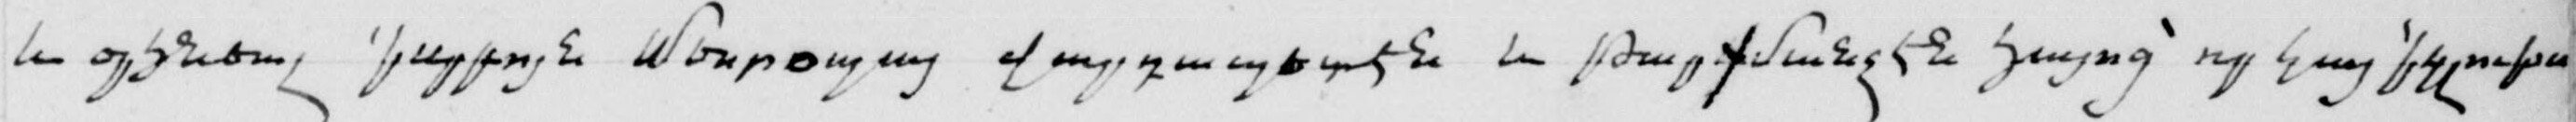

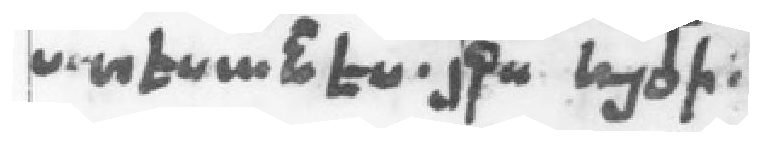

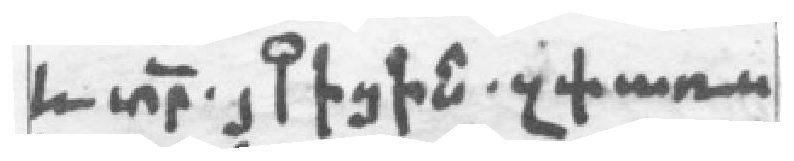

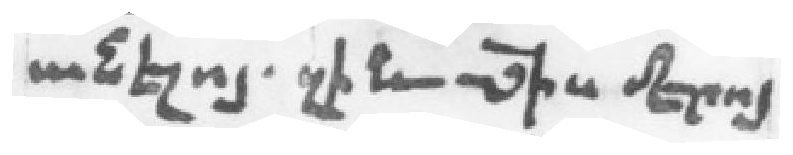

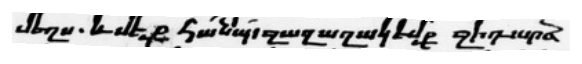

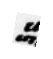

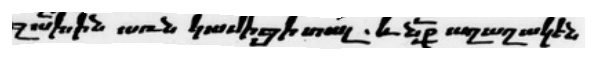

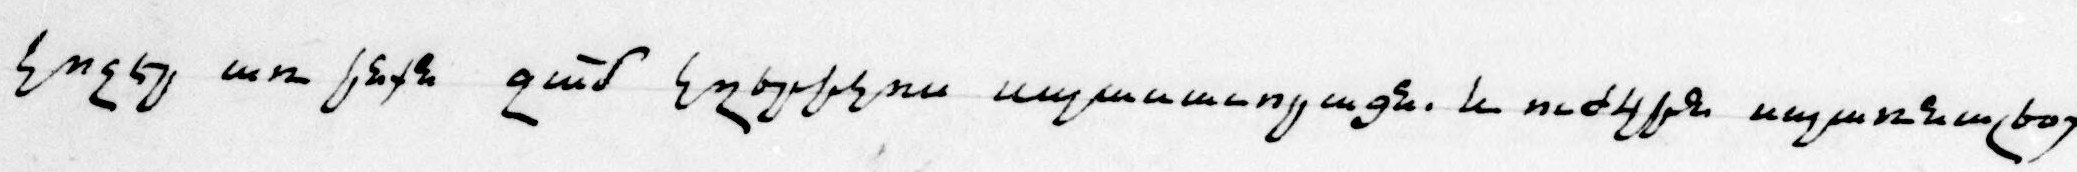

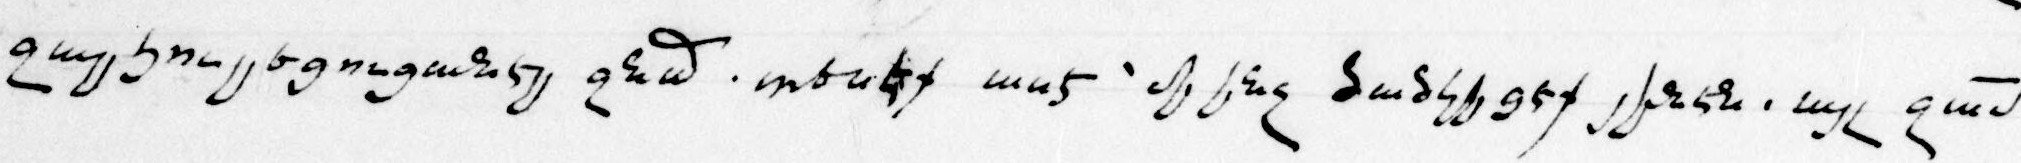

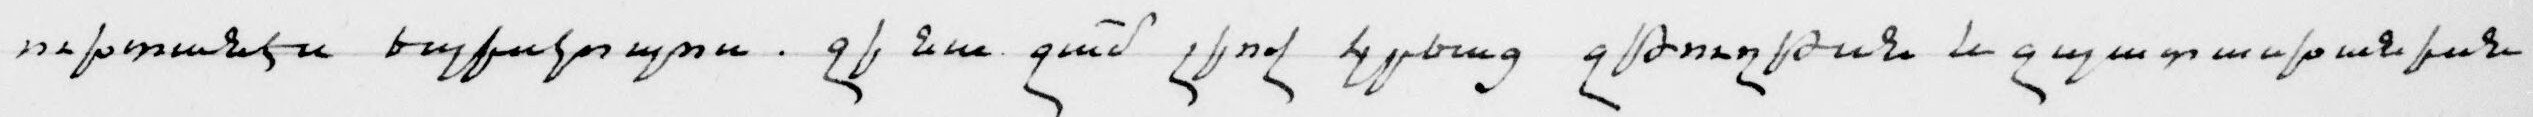

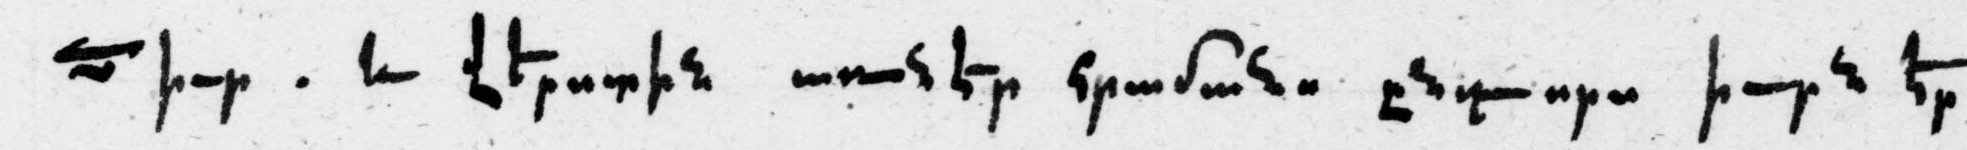

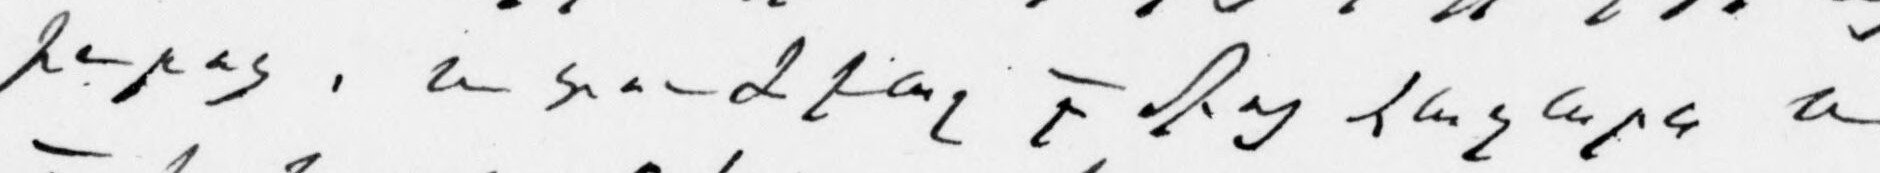

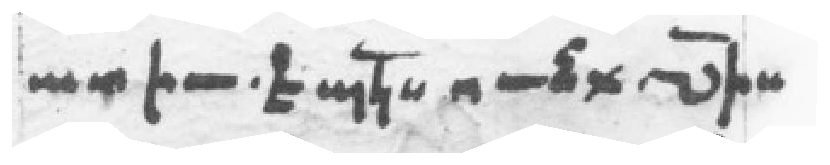

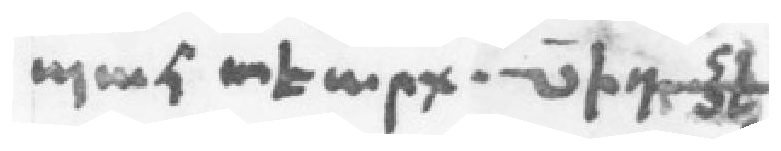

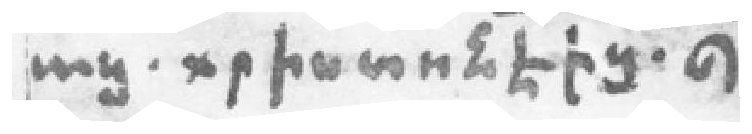

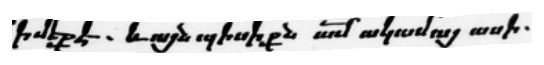

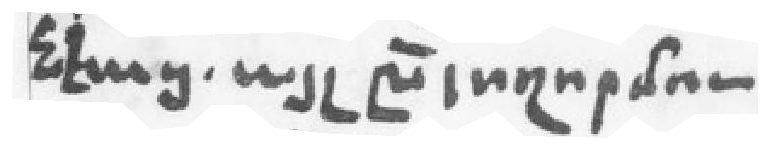

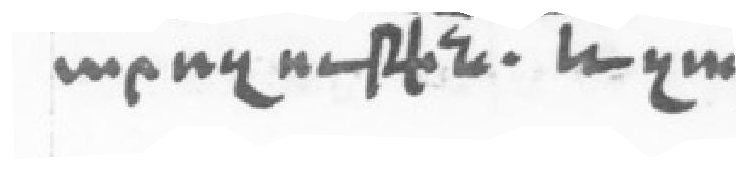

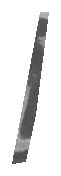

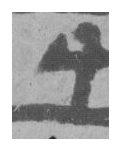

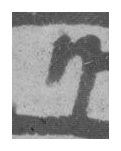

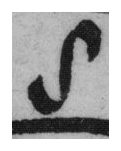

In [1]:
# Original GT strings from before cleaning. Re-run after the helper cell.
# Dropped UCLA 0011 boxes have no JPEG on disk; saved cell output keeps the crops.

DUMP_0007_052 = (
    "արոզութին․ ևզաղաւթսն զհետ բերել, զոր ի նոյն խորհուրդ արարեալ է "
    "երանելւոյն Յովհաննու Մանդակունւոյ Հայոց կաթողիկոսի՝ | Քարոզութիւն, "
    "Զարթուցեալքս, Աղաւթք, Զքէն գոհանամք և զհանգիստ նորին՝ Նայեա՛ Տէր "
    "ողորմութեամբ։"
)

CASES = [
    (
        "ms_ucla_ms__0008__043.jpg",
        "zzzzzzzցուն։czzzzzc",
        "Dummy Latin fill. Real bolorgir line; annotator typed z/c around ցուն։. Crop dropped.",
        True,
    ),
    (
        "armenian_datalab_dulaurier_0000777.jpg",
        "և օրհնեալ իսրբոյն Մեսրօպայ վարդապետէն և Թարքմանչէն hայոց՝ որ կայ իկլուխս",
        "Latin h for Armenian հ in հայոց (same line already has հ in օրհնեալ).",
        False,
    ),
    (
        "ms_p_172__0012__049.jpg",
        "ս տեսանես․ յqս ևյbի։",
        "Latin q and b in nomina sacra. Ink is յիս ևյի.",
        False,
    ),
    (
        "ms_p_172__0008__026.jpg",
        "ևտր․ յqիցին․ զփառս",
        "Latin q in յqիցին. Ink is յիսիցին.",
        False,
    ),
    (
        "ms_p_172__0013__030.jpg",
        "անելոյ․ զի և tիս մերոյ",
        "Latin t for յ in tիս. Ink is յիս.",
        False,
    ),
    (
        "ms_p_331_ff24r_34r__0009_28r__014.jpg",
        "մեղս․ ևմեք հանապıզաղաղակեմք զիդարձ",
        "Latin dotless ı (U+0131) inside հանապազ.",
        False,
    ),
    (
        "ms_p_331_ff24r_34r__0001_24r__025.jpg",
        "տı",
        "Latin ı for ի. Tiny two-letter crop տի.",
        False,
    ),
    (
        "ms_p_331_ff24r_34r__0010_28v__007.jpg",
        "զա[ղı]խին առն կամիցիտա՛լ․ ևնք աղաղակեն",
        "Calfa brackets plus Latin ı. Page shows զախին + pativ bar.",
        False,
    ),
    (
        "armenian_datalab_dulaurier_0000001.jpg",
        "կոչէր առ ինքն զամ[ենայն] կղերիկոս սպասաւորացն. և ուժգին սպառնալեօք",
        "Calfa զամ[ենայն] (letters not drawn) and ASCII period. Ink is զամ + bar, stop is միջակետ.",
        False,
    ),
    (
        "armenian_datalab_dulaurier_0000002.jpg",
        "զարհուրեցուցանէր զն[ո]ս[ա]. տեսէք ասէ՝ մի ինչ ծածկիցէք յինէն. այլ զամ[ենայն]",
        "Two expansions on one line: զն[ո]ս[ա] and զամ[ենայն], plus ASCII periods.",
        False,
    ),
    (
        "armenian_datalab_dulaurier_0001197.jpg",
        "ուխտանէս Եպիսկոպոս. զի նա զամ[ենայն] լիով կրեաց զթուղթսն և զպատասխանիսն",
        "Val example of the same զամ[ենայն] expansion.",
        False,
    ),
    (
        "armenian_datalab_dulaurier_0000678.jpg",
        "~[աշխարհ] իւր. և վերստին առնէր հրամանս ընդ որս իւրն էր",
        "Ideogram ~ already is աշխարհ. Dropped the bracket expansion; kept ~; ASCII . → ․.",
        False,
    ),
    (
        "armenian_datalab_dulaurier_0000717.jpg",
        "իւրոց, և տուժեալ ը{նդ] միոյ հազարս և",
        "{ typo for [. Same diplomatic rule as ը[նդ] → ը՟.",
        False,
    ),
    (
        "ms_p_172__0017__000.jpg",
        "ատիւ եպկսունք &իս",
        "ASCII & for և.",
        False,
    ),
    (
        "ms_p_172__0017__039.jpg",
        "պահ տեարք &իդ ձե",
        "ASCII & on զիդ (զ with a bar), not և.",
        False,
    ),
    (
        "ms_p_172__0006__012.jpg",
        "աց․ քրիստոնէից․ @",
        "Trailing @ is not ink; the letter is գ.",
        False,
    ),
    (
        "ms_p_331_ff24r_34r__0013_30r__016.jpg",
        "իմեքէ․ ևայնպիսիքն ամ ակամայ ասի/",
        "Line-final / is a mistyped վերջակետ ։.",
        False,
    ),
    (
        "ms_p_172__0016__018.jpg",
        "նեաց այլըստ|ողորմու",
        "Pipe | is a separator, not a letter.",
        False,
    ),
    (
        "ms_p_172__0007__052.jpg",
        DUMP_0007_052,
        "One-line crop (~15 letters of ink) labelled with a 208-character dump including |.",
        False,
    ),
    (
        "ms_ucla_ms__0011__044.jpg",
        "է",
        "Val gutter scratch labelled է. Degenerate Kraken polygon. Crop dropped.",
        True,
    ),
    (
        "ms_ucla_ms__0011__046.jpg",
        "գ",
        "Val 121×151 gutter box labelled գ, plus the stroke from the next line. Crop dropped.",
        True,
    ),
    (
        "ms_ucla_ms__0011__047.jpg",
        "դ",
        "Same placeholder rectangle labelled դ. Crop dropped.",
        True,
    ),
    (
        "ms_ucla_ms__0011__048.jpg",
        "մ",
        "Same placeholder rectangle labelled մ. Crop dropped.",
        True,
    ),
]

for image_name, original_gt, problem, dropped in CASES:
    show_before_after(image_name, original_gt, problem, dropped=dropped)

## 1. GT text is wrong

Historical working notes. Use the **presentation catalog** at the top for original vs cleaned GT. The dummy `z`/`c` crop was dropped.


In [26]:
# Removed from the corpus (armenian + combined pretraining train GT and image).
# Former GT: zzzzzzzցուն։czzzzzc
print("skipped ms_ucla_ms__0008__043.jpg — dropped from pretraining train")

skipped ms_ucla_ms__0008__043.jpg — dropped from pretraining train


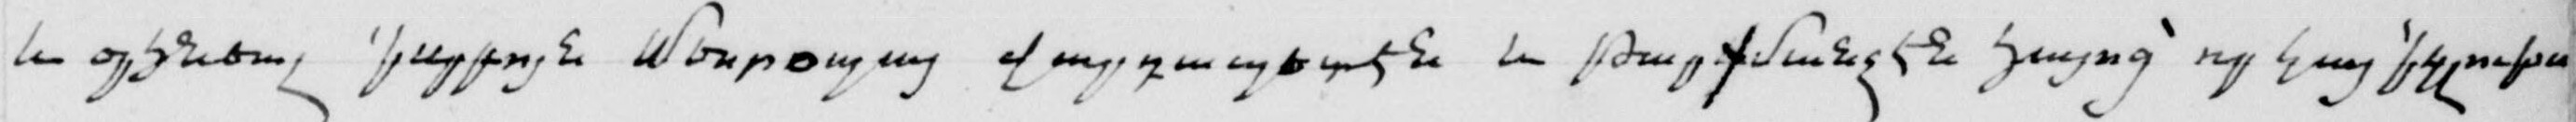

In [27]:
show_sample(
    "armenian_datalab_dulaurier_0000777.jpg",
    "GT is now հայոց with Armenian հ (U+0570), matching օրհնեալ on the same line. "
    "This sample is no longer a Latin-h leak.",
)

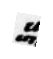

In [28]:
show_sample(
    "ms_p_331_ff24r_34r__0001_24r__025.jpg",
    "Val 2-character line. GT is տı with Latin dotless ı (U+0131) instead of Armenian ի. "
    "The crop is also a square that includes a stroke from the line below.",
)

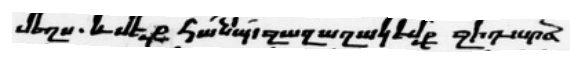

In [29]:
show_sample(
    "ms_p_331_ff24r_34r__0009_28r__014.jpg",
    "Same ı leak inside a full line. Page is closer to "
    "մեղս․ և մեք հանապազ աղաղակեմք զի դարձ. "
    "GT glued words and used ı for ա.",
)

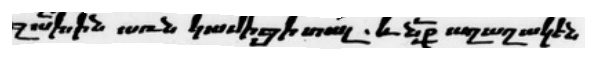

In [30]:
show_sample(
    "ms_p_331_ff24r_34r__0010_28v__007.jpg",
    "Editorial expansion զա[ղı]խին. The ink does not contain [, ], or Latin ı. "
    "Same convention as Dulaurier ամ[ենայն] lines that dominate the 14% floor.",
)

## 2. UCLA: label names a letter, crop is not a line

All four 1-character **val** samples are on UCLA page 0011. `գ`/`դ`/`մ` are identical 96×126 manual rectangles (plus 12px padding → 121×151). `է` is a degenerate Kraken polygon (a vertical scratch).

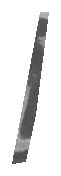

In [31]:
show_sample(
    "ms_ucla_ms__0011__044.jpg",
    "Val GT է. Kraken polygon is almost a line (2058,2541 … 2094,2390). "
    "The crop is a scratch, not the letter է.",
)

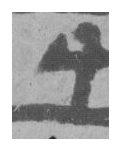

In [32]:
show_sample(
    "ms_ucla_ms__0011__046.jpg",
    "Val GT գ. Manual 96×126 gutter box. Padding pulls in the thick stroke from the next line.",
)

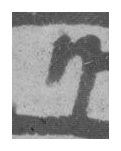

In [33]:
show_sample(
    "ms_ucla_ms__0011__047.jpg",
    "Val GT դ. Same-size placeholder rectangle as գ and մ, different gutter location. "
    "Letter is pinched between the line above and the line below.",
)

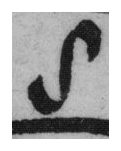

In [34]:
show_sample(
    "ms_ucla_ms__0011__048.jpg",
    "Val GT մ. Same 121×151 box. մ plus a full-width bar from the neighboring line.",
)

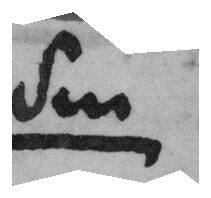

In [35]:
show_sample(
    "ms_ucla_ms__0011__045.jpg",
    "Val GT մա (2 chars) but crop is 211×198 — two letters sitting on a heavy underline.",
)

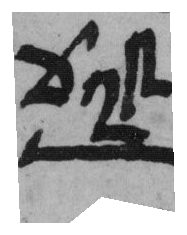

In [36]:
show_sample(
    "ms_ucla_ms__0011__043.jpg",
    "Val GT ճղթ (Armenian numerals). 187×235 square, not a text line.",
)

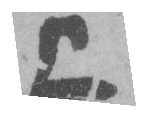

In [37]:
show_sample(
    "ms_ucla_ms__0004__044.jpg",
    "Train GT ը. Skewed polygon around one glyph; not a line crop.",
)

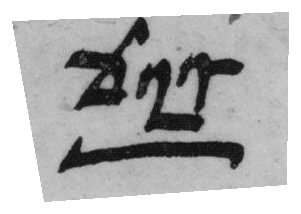

In [38]:
show_sample(
    "ms_ucla_ms__0004__045.jpg",
    "Train GT ճղդ (3 numeral letters) in a 301×214 block with a shared underline.",
)

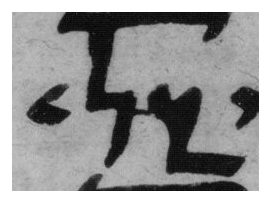

In [39]:
show_sample(
    "ms_ucla_ms__0004__046.jpg",
    "Train GT կզ (2 chars) in a 271×203 patch that also contains neighboring strokes.",
)

## 3. Editorial expansion — not a second alphabet, not ink on the page

The 46–54 character val bucket is 22% CER. Those lines are mostly Dulaurier. The mismatch is **editorial expansion**. `[` and `]` dominate the “not Armenian” count (1053 / 1059 in train, ~3.3% of all train characters — more than any rare letter). They are not `z`. They are a GT policy.

Armenian scribes almost never write every letter of a common word. They write a stem and put a bar (**pativ** / **titlo**) over it. A reader of the period knows `զամ` + bar means զամենայն (“all”). A 19th-century editor (Dulaurier’s *Recueil des historiens des croisades*, and the Calfa datalab transcription of it) wants the full dictionary form in the text, so they restore the missing letters and mark them:

```
page ink:   զամ   + a bar over ամ
GT:         զամ[ենայն]
```

The letters ե ն ա յ ն were never drawn. `[` and `]` were never drawn. They only exist in the transcription file so a human can see “this part was abbreviated.”

That is why the brackets are almost only Dulaurier: 489 of 1158 Dulaurier train lines use this markup. P331 has one (`զա[ղı]խին`, which is also the `ı` typo). UCLA does not. So this is a **Dulaurier GT convention**, not a character class that belongs because it appears in the ink.

Keep expanded GT and you accept a CER floor against abbreviated pages. Transcribe the stem as written and the brackets leave the alphabet. Either way, this is not stray alphabet dirt like `z` / `ı`.

Train characters: 63291
'[' count: 1053
']' count: 1059
Brackets as % of all train chars: 3.34%

  dulaurier  lines=1158  with_[_]=  489
  p331       lines= 348  with_[_]=    1
  ucla       lines= 136  with_[_]=    0
  p172       lines= 165  with_[_]=    0


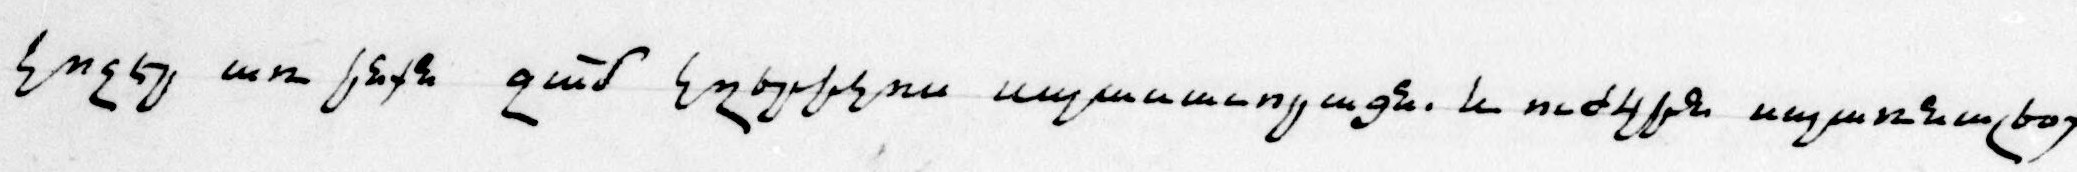

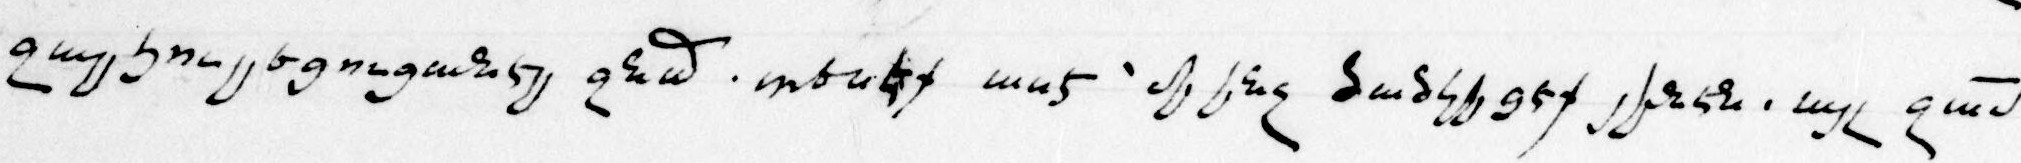

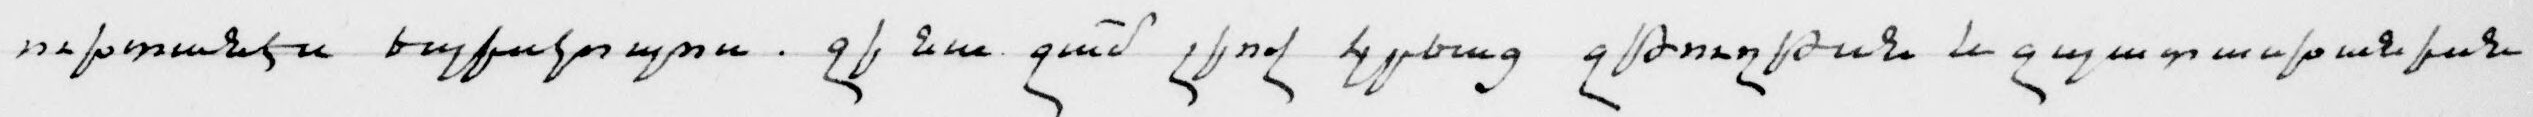

In [40]:
from collections import Counter


def source_of(name: str) -> str:
    if name.startswith("armenian_datalab"):
        return "dulaurier"
    if name.startswith("ms_p_331"):
        return "p331"
    if name.startswith("ms_ucla"):
        return "ucla"
    if name.startswith("ms_p_172"):
        return "p172"
    return "other"


rows = []
for line in (DATA / "gt_train.txt").read_text(encoding="utf-8").splitlines():
    name, text = line.split("\t", 1)
    rows.append((name, text, source_of(name)))

n_chars = sum(len(text) for _, text, _ in rows)
print(f"Train characters: {n_chars}")
print(f"'[' count: {sum(text.count('[') for _, text, _ in rows)}")
print(f"']' count: {sum(text.count(']') for _, text, _ in rows)}")
print(f"Brackets as % of all train chars: {(sum(text.count('[') + text.count(']') for _, text, _ in rows) / n_chars):.2%}")
print()
for src in ("dulaurier", "p331", "ucla", "p172"):
    subset = [text for _, text, s in rows if s == src]
    n_br = sum("[" in text or "]" in text for text in subset)
    print(f"  {src:10} lines={len(subset):4}  with_[_]= {n_br:4}")

show_sample(
    "armenian_datalab_dulaurier_0000001.jpg",
    "Textbook expansion. Page ink is զամ + a pativ/titlo bar over ամ. "
    "GT writes զամ[ենայն]: ե ն ա յ ն and the brackets were never drawn. "
    "A period reader expands this to 'all' without those letters being on the line.",
)
show_sample(
    "armenian_datalab_dulaurier_0000002.jpg",
    "Same convention twice on one line: զն[ո]ս[ա] and զամ[ենայն]. "
    "The model can memorize the expansion on frequent train phrases (CER 0 here) "
    "and still lose on rarer abbreviations in val — that is the 14% floor, not the 13 isolated 1-char rows.",
)
show_sample(
    "armenian_datalab_dulaurier_0001197.jpg",
    "Val. Same markup: զամ[ենայն]. Compare the crop (stem + bar) with the GT (full dictionary form in brackets).",
)

## 4. Contrast: 1-character crops that are fine

P331 initials are tight. Dulaurier digits are page numbers. These can stay.

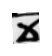

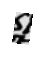

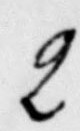

In [41]:
show_sample(
    "ms_p_331_ff24r_34r__0002_24v__001.jpg",
    "Clean P331 1-character initial ճ at ~45×56. Keep.",
)
show_sample(
    "ms_p_331_ff24r_34r__0008_27v__001.jpg",
    "Clean P331 1-character դ. Keep.",
)
show_sample(
    "armenian_datalab_dulaurier_0000350.jpg",
    "Dulaurier page-number 2. Tight crop, GT matches the ink. Keep.",
)

## 5. Three different “period” classes

These are not one punctuation mark. The train GT treats them as three codec classes:

| Glyph | Unicode | Train n | What it is |
|---|---|---|---|
| `.` | U+002E ASCII period | 263 | Western full stop, mostly Dulaurier print |
| `։` | U+0589 Armenian full stop | 285 | The real Armenian verse/sentence mark (two dots) |
| `․` | U+2024 one-dot leader | 375 | Looks like a period; used on P331 as the manuscript point |

A mixed Dulaurier line can have `.` and `։` in the same GT string. The model has to pick which “dot” class the ink meant. That is label noise, not a missing letter.

## 6. Digits and rare capitals are real page ink

Digits `0–9` are 71 hits, almost all **page numbers** (Dulaurier printed foliation, P331 folio numbers). They belong if you keep those crops — see also the `2` in section 4.

Low-frequency Armenian **capitals** (n = 1–5: Է, Ձ, Ղ, Ճ, Ծ, Ք, …) are headings and names, not junk. Do not drop them with `z` / `{`.

## 7. Rare punctuation that *is* junk

Unlike Ք, these marks are transcription accidents. They should not stay in the alphabet.

- `{` once — `ը{նդ]` is a typo for `ը[նդ]` (wrong bracket).
- `"` once — stray ASCII quote on a P331 line-end.
- `«` once — a lone left guillemet with no `»`.
- `~` five times — all Dulaurier `~[աշխարհ]`, another expansion gadget on top of `[` `]`.

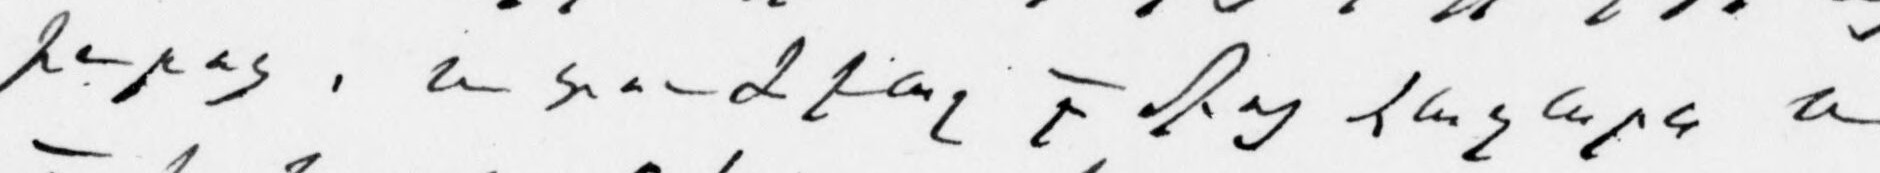

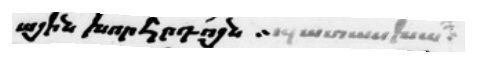

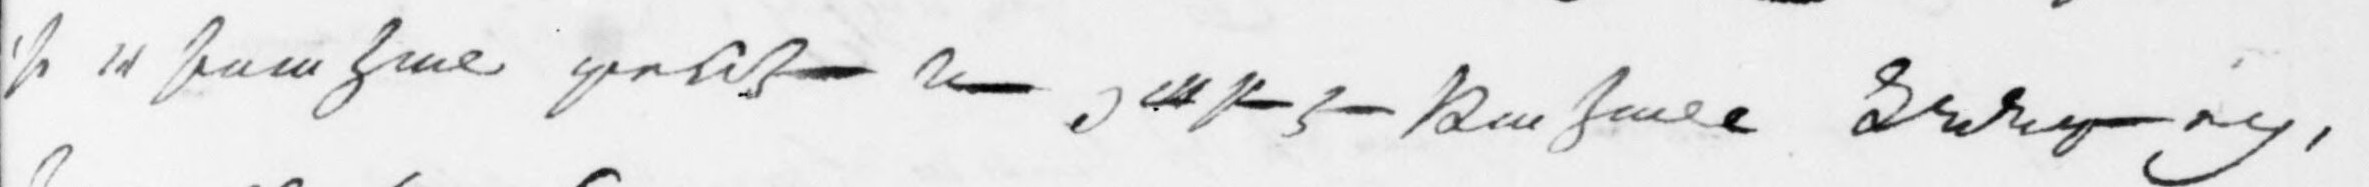

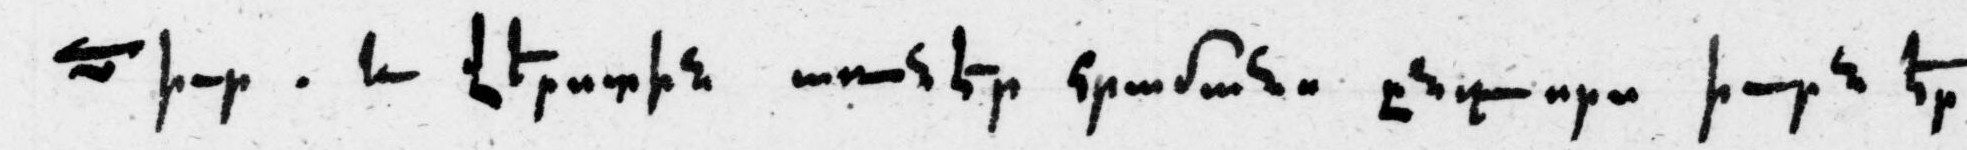

In [42]:
show_sample(
    "armenian_datalab_dulaurier_0000717.jpg",
    "ը{նդ] is a typo for ը[նդ]. '{' is not Armenian punctuation; it is a mistyped '['.",
)
show_sample(
    "ms_p_331_ff24r_34r__0008_27v__009.jpg",
    "Stray ASCII '\"' at the end of պատասխա\". Not an Armenian quote mark.",
)
show_sample(
    "armenian_datalab_dulaurier_0000946.jpg",
    "Lone '«' in ի «իսական. No matching »; leftover print/editor mark.",
)
show_sample(
    "armenian_datalab_dulaurier_0000678.jpg",
    "~[աշխարհ] is the same expansion policy as զամ[ենայն], plus a tilde the page does not show. Five train/val hits, all this lemma.",
)

## 8. Finetuning has more Latin leftovers

These are **not** in the current pretraining train set. They would be added if you fine-tune with charset expansion on.

MS_P_172 mixes Latin lookalikes into Armenian words (`յqս ևյbի`, `tիս`) plus editor/markup leftovers `&`, `@`, `/`, `|`. The pretrained `final/best.pt` has never seen `q`/`b`/`t` as classes; at finetune time they become new codec symbols unless you fix the GT first.

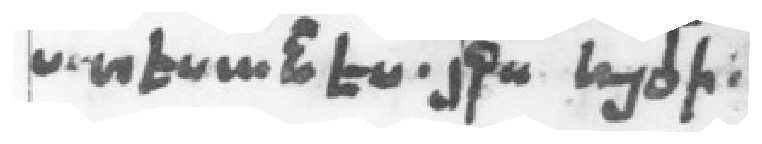

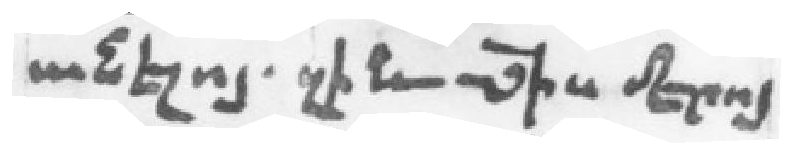

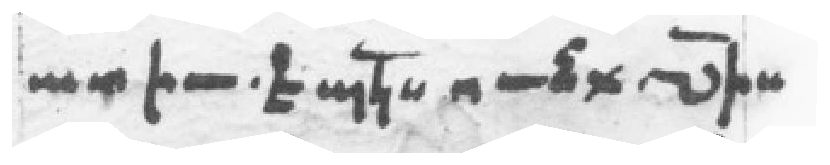

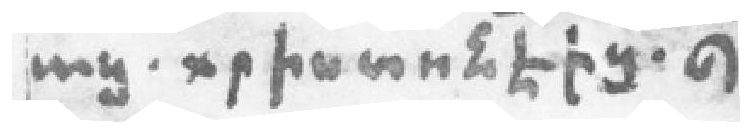

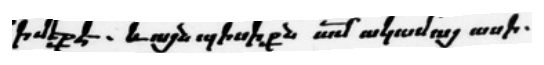

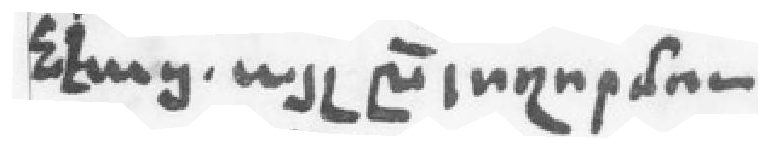

In [43]:
show_sample(
    "ms_p_172__0012__049.jpg",
    "Finetune train. Latin q and b inside Armenian: յqս ևյbի. Ink is almost certainly յս / յի (or similar); the Latin letters are leftover typing.",
)
show_sample(
    "ms_p_172__0013__030.jpg",
    "Finetune train. Latin t in tիս մերոյ — should be տիս (or the Armenian word on the page), not ASCII t.",
)
show_sample(
    "ms_p_172__0017__000.jpg",
    "Finetune val. '&իս' is not an Armenian conjunction; '&' is a Latin leftover.",
)
show_sample(
    "ms_p_172__0006__012.jpg",
    "Finetune train. Trailing '@' — not page ink.",
)
show_sample(
    "ms_p_331_ff24r_34r__0013_30r__016.jpg",
    "Finetune train. Line-final '/' — editor/line-break junk.",
)
show_sample(
    "ms_p_172__0016__018.jpg",
    "Pretraining val (also the kind of leftover finetune would keep). 'այլըստ|ողորմու' — '|' is not an Armenian letter.",
)

## 9. Cleanup that actually changes the alphabet

These rows are **already cleaned** (see the presentation catalog). The notes below are historical. The saved Calamari charset still lists `z`/`c`/`h` until you retrain.


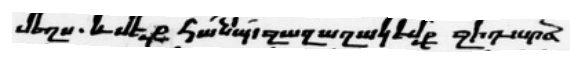

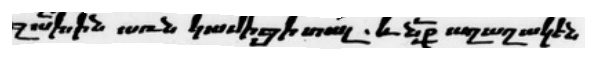

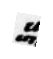

In [44]:
show_sample(
    "ms_p_331_ff24r_34r__0009_28r__014.jpg",
    "Still to fix: հանապıզ should be հանապիզ. Latin ı (U+0131) for Armenian ի (U+056B).",
)
show_sample(
    "ms_p_331_ff24r_34r__0010_28v__007.jpg",
    "Still to fix: զա[ղı]խին — ı→ի, and this is also the only P331 expansion-bracket line.",
)
show_sample(
    "ms_p_331_ff24r_34r__0001_24r__025.jpg",
    "Val. տı is two codepoints (տ + ı). Intended տի. Combined pretraining still has this row in train as well.",
)

## 10. Leftover GT typos still in the manifests

Historical. Every row in this section is now in the presentation catalog with original vs cleaned GT. Remaining short UCLA/P331 boxes were left on purpose (real margin ink).


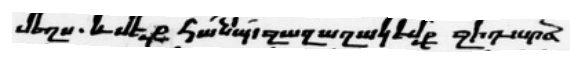

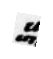

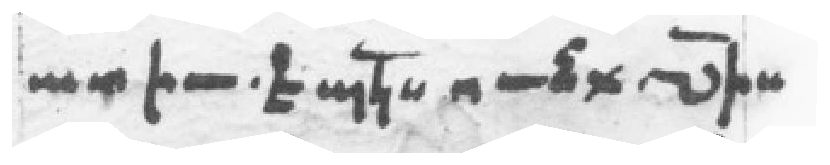

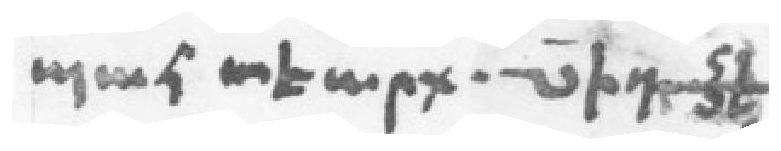

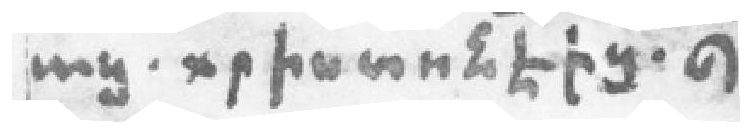

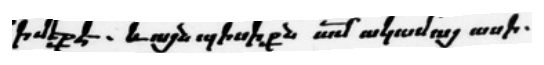

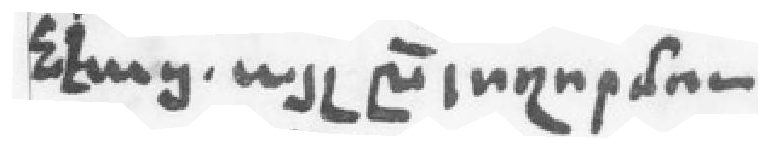

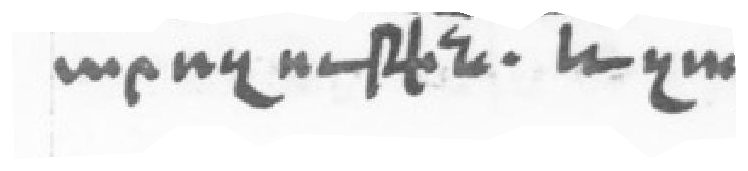

In [45]:
show_sample(
    "ms_p_331_ff24r_34r__0009_28r__014.jpg",
    "Pretrain train. Latin dotless ı (U+0131) inside հանապıզ. The word on the page is հանապազ (always), not հանապիզ.",
)
show_sample(
    "ms_p_331_ff24r_34r__0001_24r__025.jpg",
    "Pretrain val. տı is տ + Latin ı. Intended տի. Tiny square crop; also still in combined pretraining train.",
)
show_sample(
    "ms_p_172__0017__000.jpg",
    "Finetune val. &իս — Latin ampersand, not Armenian և.",
)
show_sample(
    "ms_p_172__0017__039.jpg",
    "Finetune val. Second &: &իդ.",
)
show_sample(
    "ms_p_172__0006__012.jpg",
    "Finetune train. Trailing @ is not page ink.",
)
show_sample(
    "ms_p_331_ff24r_34r__0013_30r__016.jpg",
    "Finetune train. Line-final / — editor/line-break junk.",
)
show_sample(
    "ms_p_172__0016__018.jpg",
    "Pretrain val. այլըստ|ողորմու — | is not an Armenian letter.",
)
show_sample(
    "ms_p_172__0007__052.jpg",
    "Finetune test. Crop is a normal ~15-letter line; GT is 208 characters dumped onto it (including |). This one row is most of finetune test CER.",
)

In [ ]:
## 11. Folio numbers and gutter boxes — every 1–3 character crop

These are still in both pretraining and finetuning. The GT string can be Armenian (`ռճ`, `գ`, `ճխ`) or Western (`24`, `69`) and still not be a text line: the crop is a margin numeral, a UCLA gutter rectangle, or a scratch.

| stage / split | count |
|---------------|------:|
| pretrain train / val / test | 118 / 17 / 16 |
| finetune train / val / test | 110 / 7 / 13 |
| **total** | **281** |

Next cell draws a labelled contact sheet for all 281 (no model call). Look at the crop, not the Unicode. A few 2–3 character strings in the same bucket are real word fragments (`այլ`, `ըստ`, `ոք`); they are mixed in so you can tell them apart.


1–3 character crops: 281
by stage/split: {'pretraining/train': 118, 'pretraining/val': 17, 'pretraining/test': 16, 'finetuning/train': 110, 'finetuning/val': 7, 'finetuning/test': 13}
by source: {'p331': 98, 'dulaurier': 41, 'p172': 54, 'ucla': 88}
digit-only (Western folio): 44


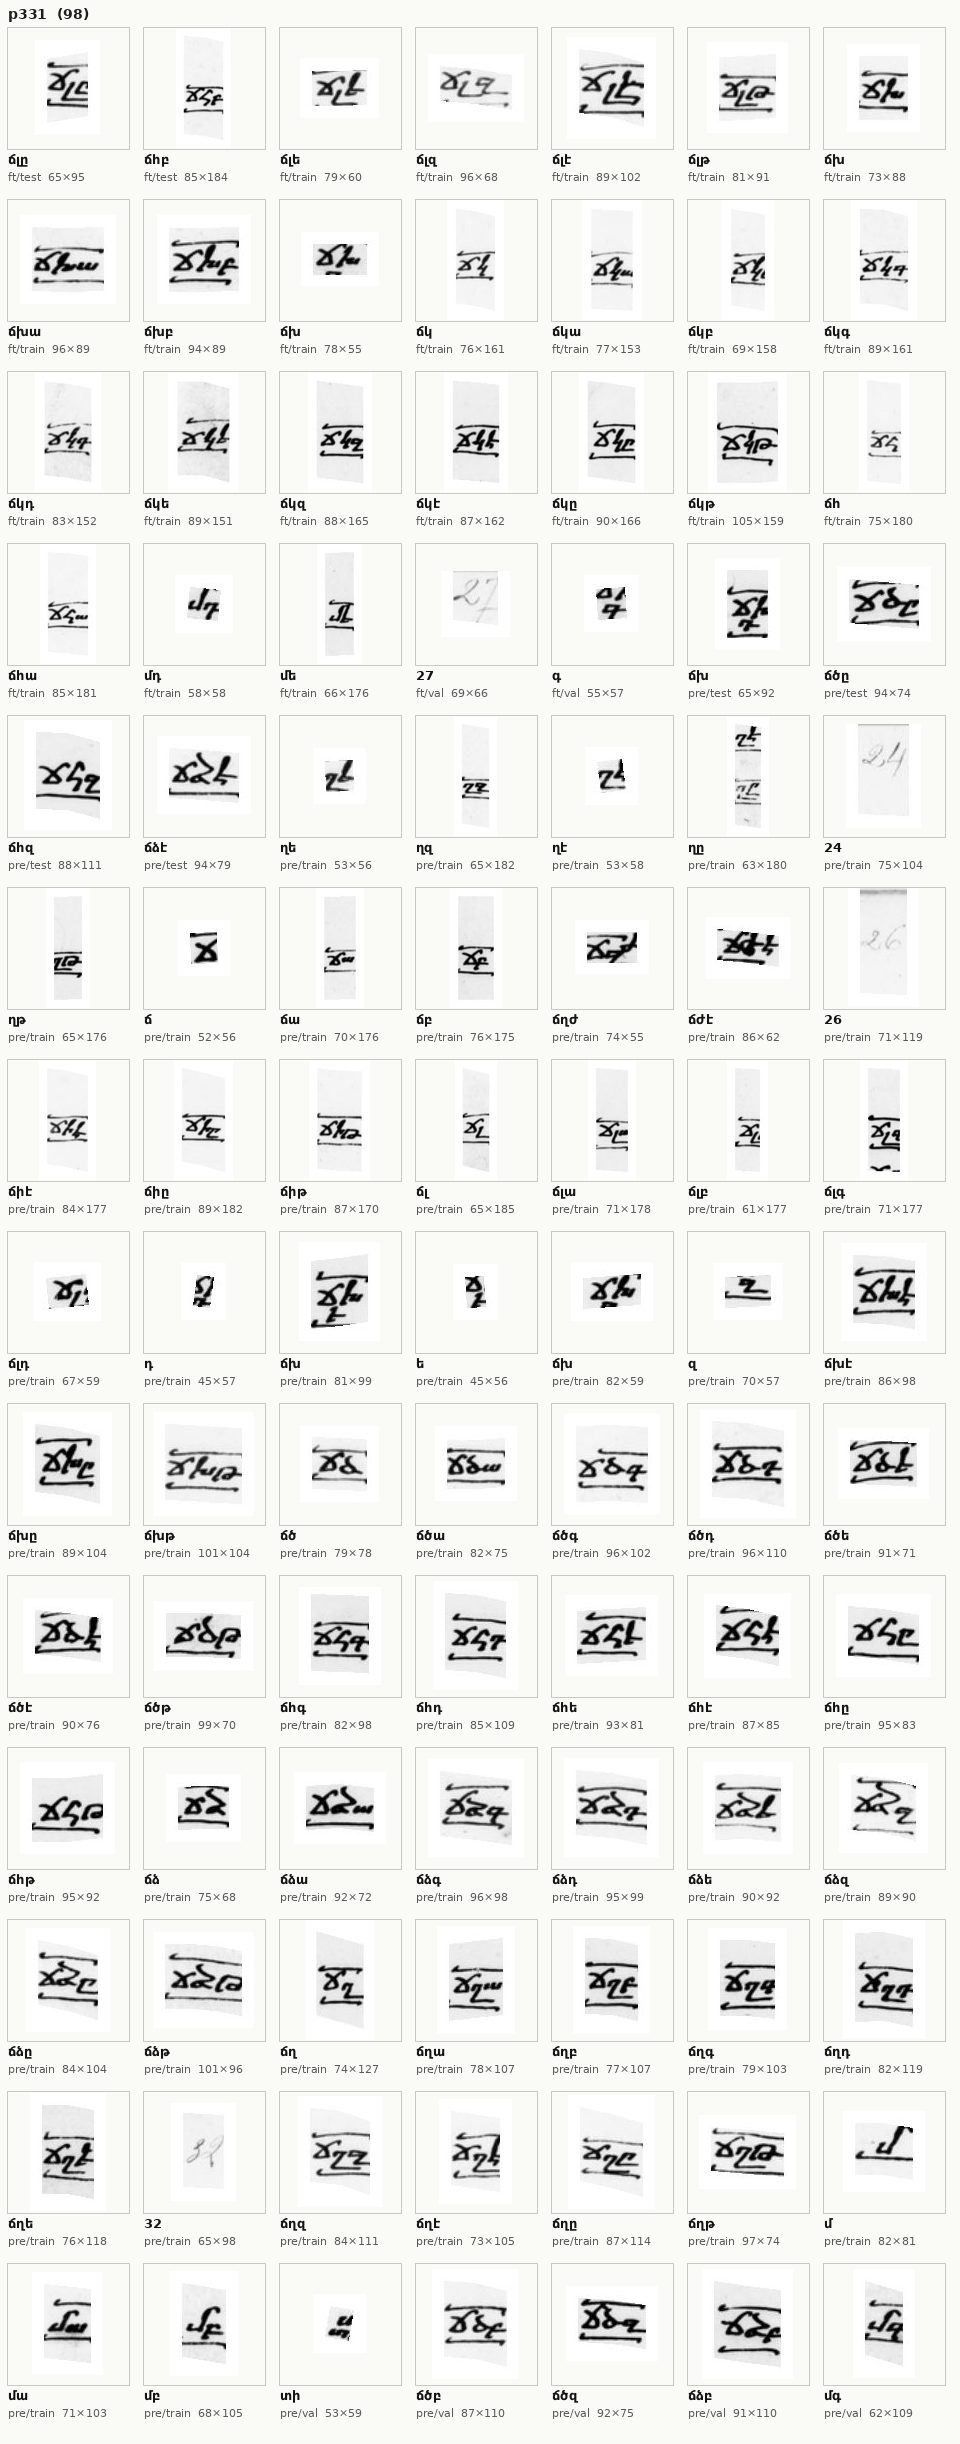

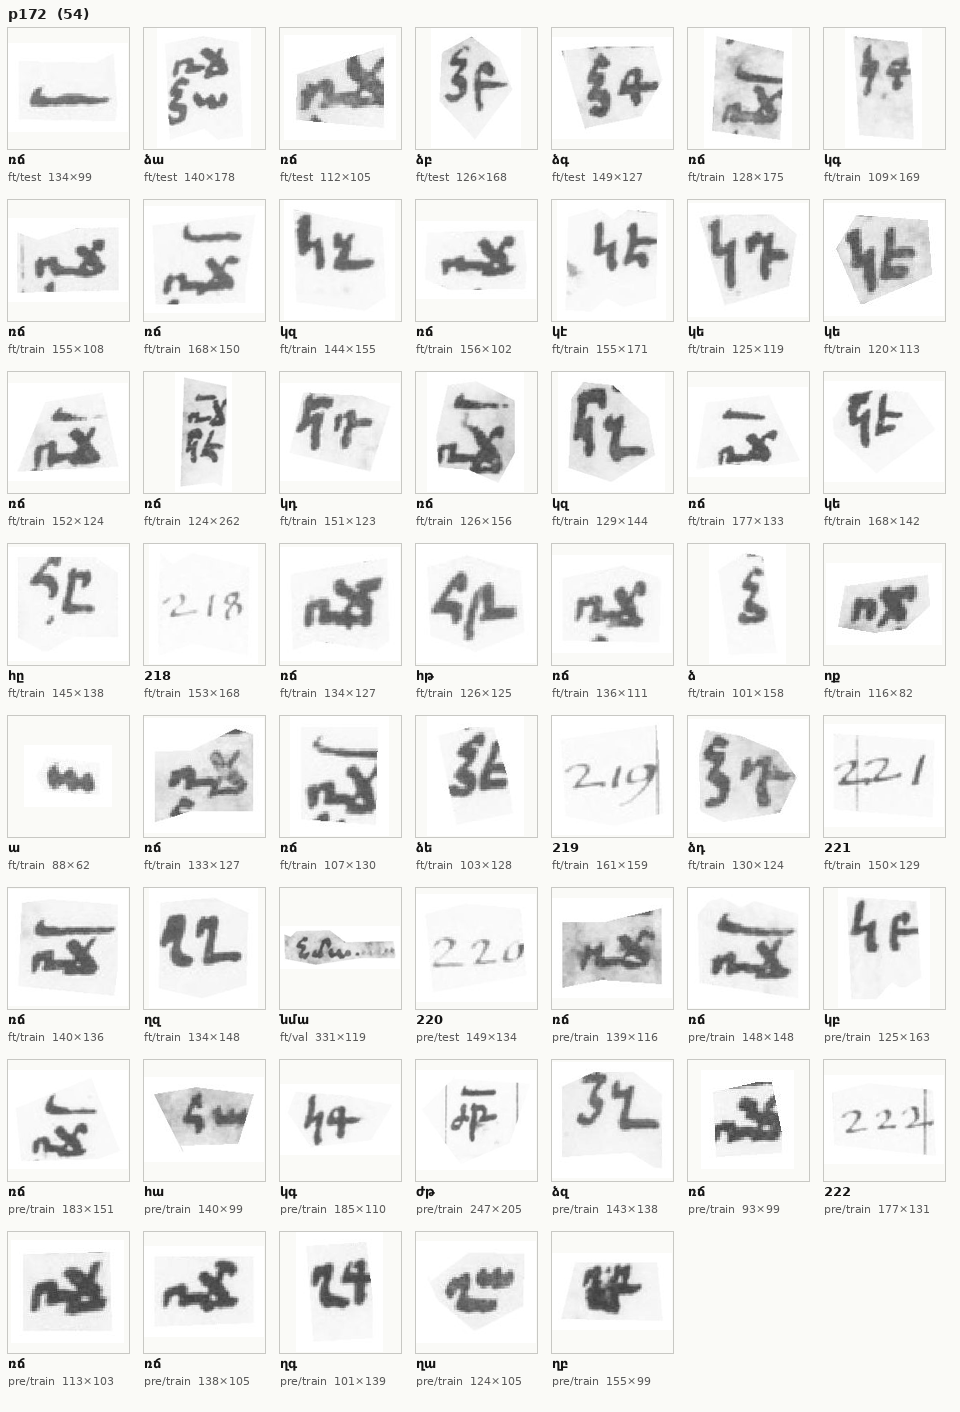

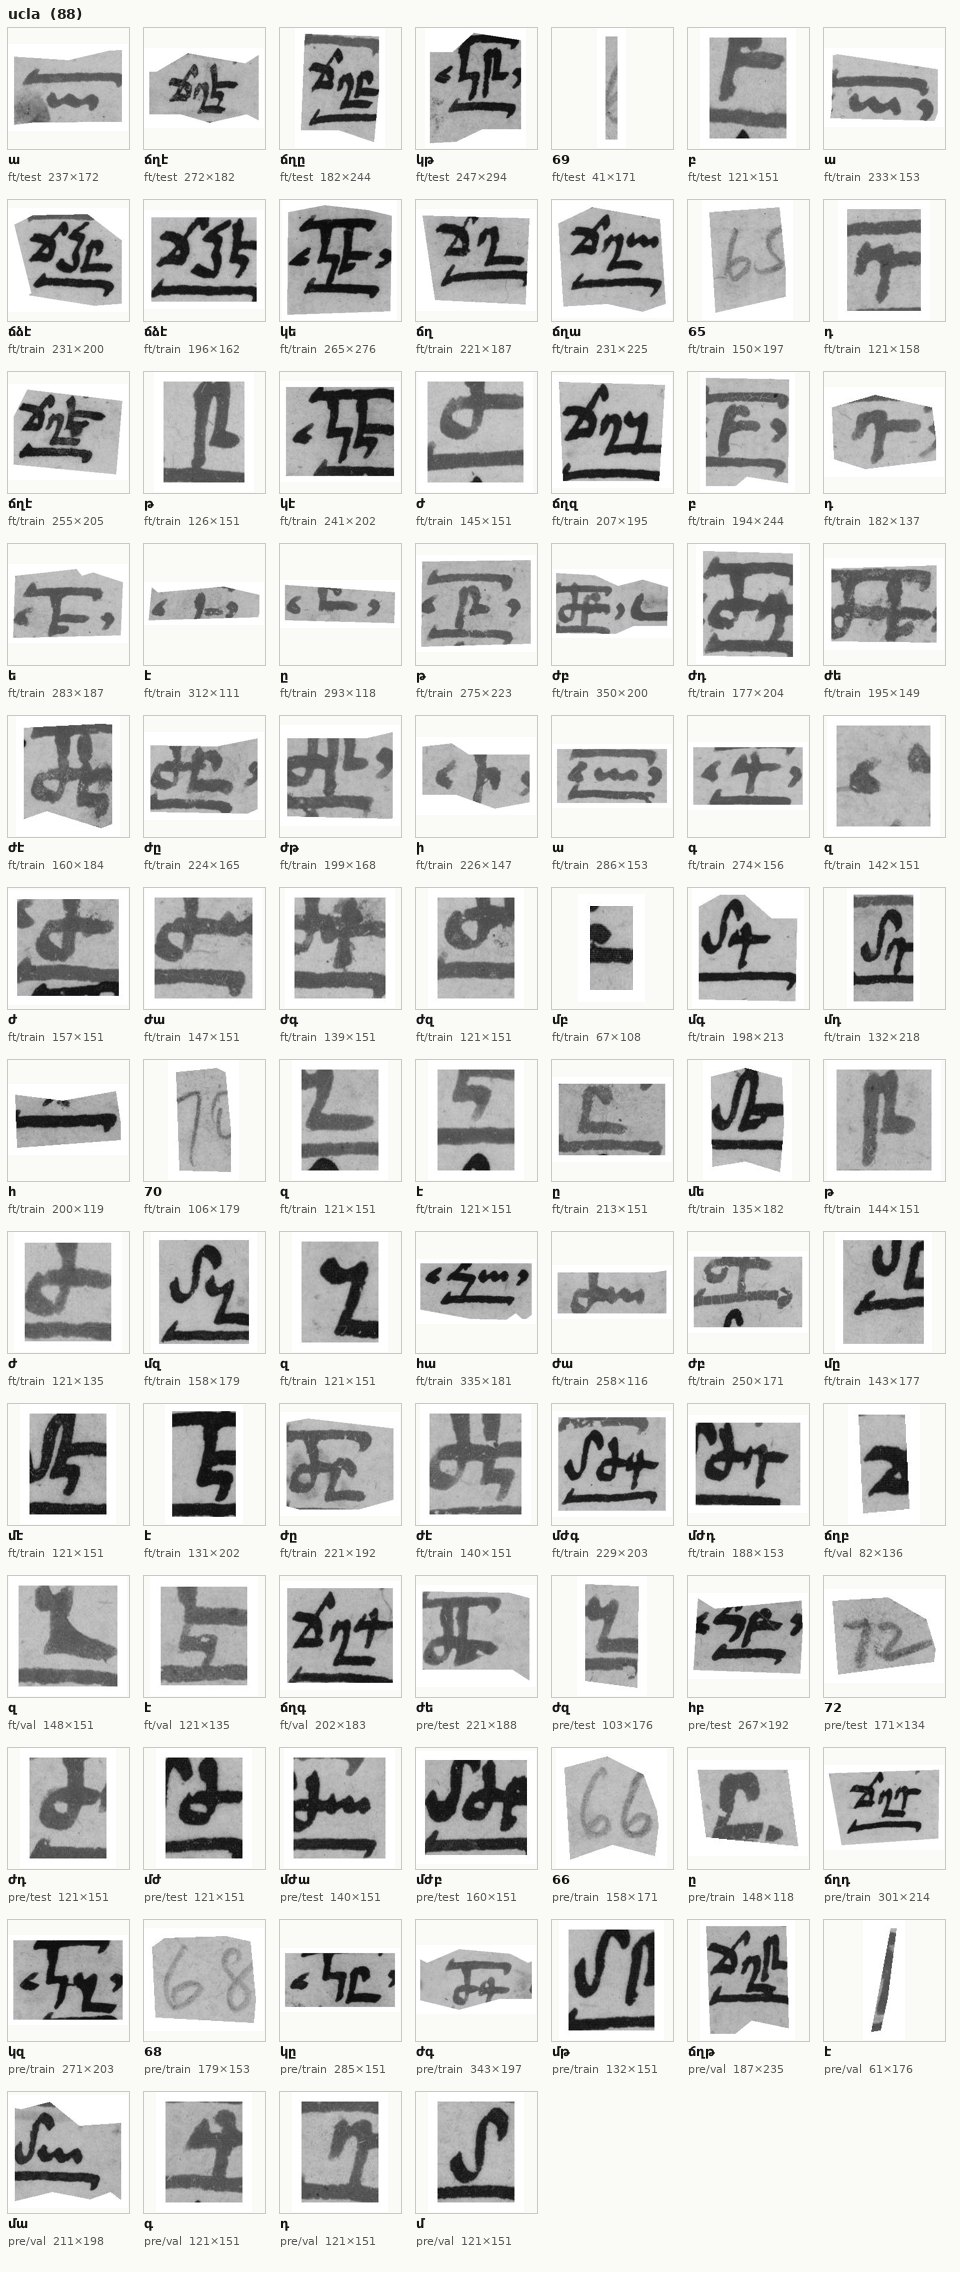

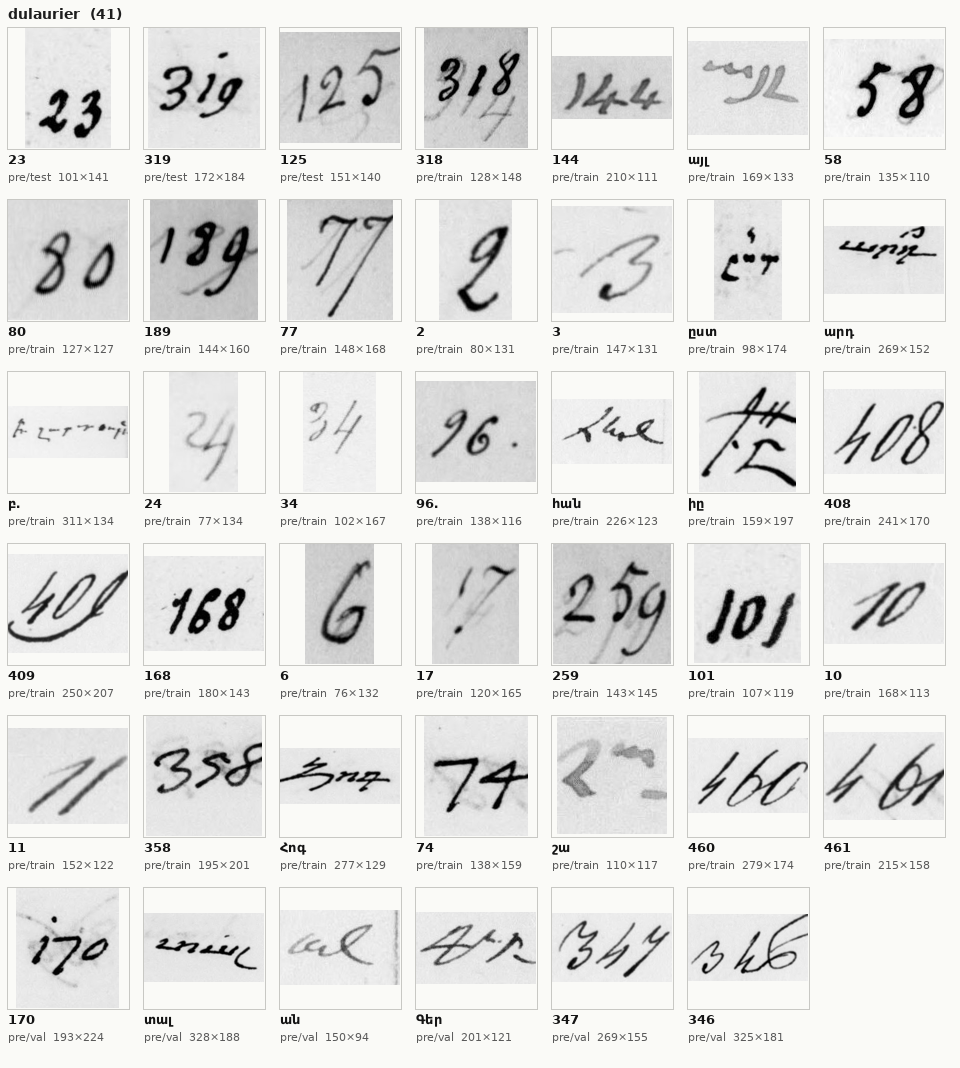

In [47]:
from collections import Counter
import math

from PIL import ImageDraw, ImageFont


SHORT_MAX = 3
THUMB = 120
CAPTION_H = 44
COLS = 7
PAD = 8
FONT = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 11)
FONT_GT = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 13)
FONT_TITLE = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 14)


def short_source(name: str) -> str:
    if name.startswith("armenian_datalab"):
        return "dulaurier"
    if name.startswith("ms_p_331"):
        return "p331"
    if name.startswith("ms_p_172"):
        return "p172"
    if name.startswith("ms_ucla"):
        return "ucla"
    return "other"


def collect_short_crops(max_len: int = SHORT_MAX) -> list[dict]:
    rows = []
    for partition in ("pretraining", "finetuning"):
        data = ARMENIAN / partition
        for split in ("train", "val", "test"):
            gt_path = data / f"gt_{split}.txt"
            image_dir = data / "image"
            for line in gt_path.read_text(encoding="utf-8").splitlines():
                name, text = line.split("\t", 1)
                if len(text.strip()) > max_len:
                    continue
                path = image_dir / name
                if not path.is_file():
                    continue
                with PILImage.open(path) as image:
                    width, height = image.size
                rows.append(
                    {
                        "name": name,
                        "gt": text,
                        "split": f"{partition}/{split}",
                        "source": short_source(name),
                        "path": path,
                        "size": (width, height),
                    }
                )
    return rows


def make_contact_sheet(title: str, rows: list[dict]) -> PILImage.Image:
    n = len(rows)
    grid_rows = math.ceil(n / COLS)
    cell_w = THUMB + 2 * PAD
    cell_h = THUMB + CAPTION_H + PAD
    sheet = PILImage.new(
        "RGB",
        (COLS * cell_w + PAD, 28 + grid_rows * cell_h + PAD),
        (250, 250, 247),
    )
    draw = ImageDraw.Draw(sheet)
    draw.text((PAD, 6), f"{title}  ({n})", font=FONT_TITLE, fill=(30, 30, 30))
    for i, row in enumerate(rows):
        r, c = divmod(i, COLS)
        x = PAD + c * cell_w
        y = 28 + r * cell_h
        with PILImage.open(row["path"]) as image:
            thumb = image.convert("RGB")
            thumb.thumbnail((THUMB, THUMB))
        ox = x + (THUMB - thumb.width) // 2
        oy = y + (THUMB - thumb.height) // 2
        sheet.paste(thumb, (ox, oy))
        draw.rectangle(
            [x - 1, y - 1, x + THUMB + 1, y + THUMB + 1],
            outline=(200, 200, 196),
        )
        split = row["split"].replace("pretraining/", "pre/").replace("finetuning/", "ft/")
        width, height = row["size"]
        draw.text((x, y + THUMB + 3), row["gt"], font=FONT_GT, fill=(20, 20, 20))
        draw.text(
            (x, y + THUMB + 22),
            f"{split}  {width}×{height}",
            font=FONT,
            fill=(90, 90, 90),
        )
    return sheet


short_rows = collect_short_crops()
print(f"1–3 character crops: {len(short_rows)}")
print("by stage/split:", dict(Counter(r["split"] for r in short_rows)))
print("by source:", dict(Counter(r["source"] for r in short_rows)))
print("digit-only (Western folio):", sum(r["gt"].isdigit() for r in short_rows))

order = ("p331", "p172", "ucla", "dulaurier")
for source in order:
    group = [r for r in short_rows if r["source"] == source]
    group.sort(key=lambda r: (r["split"], r["name"]))
    display(HTML(f"<h3>{source}</h3>"))
    display(make_contact_sheet(source, group))


## 12. Same page, real pixel size — what “wide strip” means

Section 11 **zooms** every thumbnail to the same box, so a 79×60 margin number looks as big as a sentence. That is why this is hard to see.

Ignore the Unicode. Look only at **shape**.

On one folio of P331 (`27r`) we have two kinds of crop:

1. **A text line** — a long thin ribbon (~580×60). One row of handwriting, ~30 letters. This is what Calamari is for.
2. **A margin number** — a small square (~80×80). Two or three letters (`ճլե`, `27`) from the gutter, not a sentence.

They are **not** a wrong reading of the same line. They are two different objects cut off the same page. The next cell pastes both onto **one picture at 1:1** (no zoom), so the ribbons stay long and the numbers stay small.


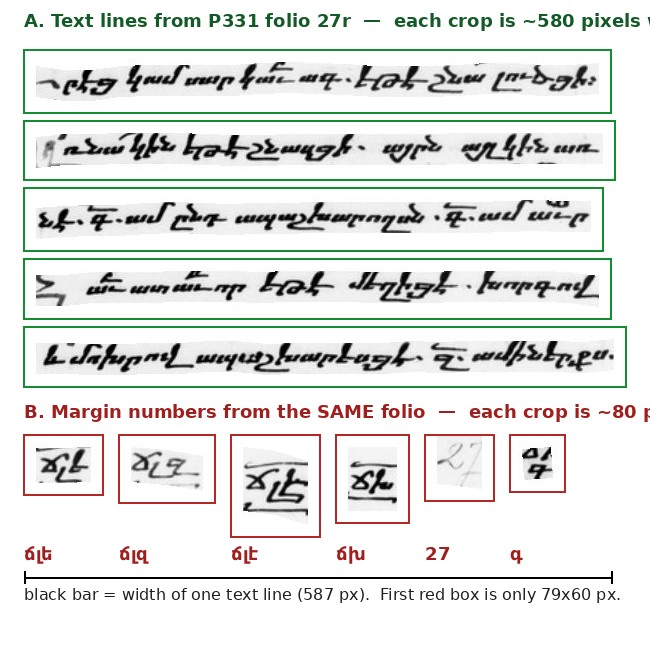

Green (text lines)
  587x63  Էրէց կամ սարկաւագ․ եթէ շնա՛ լուծցի։
  591x59  Առնա՛կին եթէշնասցի․ այրն այլկինառ
  579x63  նէ ․գ․ ամ ընդ ապաշխարողսն ․գ․ ամ աւր
  587x60  Հ աւատաւոր եթէ մեղիցէ․ խորգով
  602x60  ևմոխրով ապաշխարեսցէ ․զ․ ամիներքս․
Red (margin numbers)
  79x60  GT='ճլե'  ms_p_331_ff24r_34r__0007_27r__028.jpg
  96x68  GT='ճլզ'  ms_p_331_ff24r_34r__0007_27r__029.jpg
  89x102  GT='ճլէ'  ms_p_331_ff24r_34r__0007_27r__030.jpg
  73x88  GT='ճխ'  ms_p_331_ff24r_34r__0007_27r__033.jpg
  69x66  GT='27'  ms_p_331_ff24r_34r__0007_27r__027.jpg
  55x57  GT='գ'  ms_p_331_ff24r_34r__0007_27r__037.jpg


In [1]:
from PIL import ImageDraw, ImageFont

FONT = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 16)
FONT_BIG = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 20)
FONT_ARM = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 18)

PAGE = "ms_p_331_ff24r_34r__0007_27r"
LINE_NAMES = [
    "ms_p_331_ff24r_34r__0007_27r__000.jpg",
    "ms_p_331_ff24r_34r__0007_27r__001.jpg",
    "ms_p_331_ff24r_34r__0007_27r__002.jpg",
    "ms_p_331_ff24r_34r__0007_27r__004.jpg",
    "ms_p_331_ff24r_34r__0007_27r__005.jpg",
]
STAMP_NAMES = [
    "ms_p_331_ff24r_34r__0007_27r__028.jpg",
    "ms_p_331_ff24r_34r__0007_27r__029.jpg",
    "ms_p_331_ff24r_34r__0007_27r__030.jpg",
    "ms_p_331_ff24r_34r__0007_27r__033.jpg",
    "ms_p_331_ff24r_34r__0007_27r__027.jpg",
    "ms_p_331_ff24r_34r__0007_27r__037.jpg",
]


def load_row(image_name: str) -> tuple[PILImage.Image, str, str]:
    split, gt, path = lookup_gt(image_name)
    with PILImage.open(path) as image:
        rgb = image.convert("RGB")
    return rgb, gt, split


lines = [load_row(name) for name in LINE_NAMES]
stamps = [load_row(name) for name in STAMP_NAMES]

left = 24
gap = 8
title_h = 56
label_h = 36
line_block_h = title_h + sum(im.height + gap for im, _, _ in lines)
stamp_h = max(im.height for im, _, _ in stamps)
stamp_block_h = 70 + stamp_h + 50
width = max(im.width for im, _, _ in lines) + 2 * left
height = line_block_h + stamp_block_h + 40
canvas = PILImage.new("RGB", (width, height), (255, 255, 255))
draw = ImageDraw.Draw(canvas)

draw.text(
    (left, 12),
    "A. Text lines from P331 folio 27r  —  each crop is ~580 pixels wide, ~60 tall",
    font=FONT_BIG,
    fill=(20, 90, 40),
)

y = title_h
for image, gt, split in lines:
    canvas.paste(image, (left, y))
    draw.rectangle(
        [left - 1, y - 1, left + image.width, y + image.height],
        outline=(20, 140, 50),
        width=2,
    )
    y += image.height + gap

draw.text(
    (left, y + 8),
    "B. Margin numbers from the SAME folio  —  each crop is ~80 pixels wide. Not zoomed.",
    font=FONT_BIG,
    fill=(160, 30, 30),
)

stamp_y = y + 44
x = left
for image, gt, split in stamps:
    canvas.paste(image, (x, stamp_y))
    draw.rectangle(
        [x - 1, stamp_y - 1, x + image.width, stamp_y + image.height],
        outline=(180, 40, 40),
        width=2,
    )
    draw.text((x, stamp_y + stamp_h + 6), gt, font=FONT_ARM, fill=(160, 30, 30))
    x += image.width + 16

ruler_y = stamp_y + stamp_h + 40
draw.line([(left, ruler_y), (left + lines[0][0].width, ruler_y)], fill=(0, 0, 0), width=2)
draw.line([(left, ruler_y - 6), (left, ruler_y + 6)], fill=(0, 0, 0), width=2)
draw.line(
    [(left + lines[0][0].width, ruler_y - 6), (left + lines[0][0].width, ruler_y + 6)],
    fill=(0, 0, 0),
    width=2,
)
w0, h0 = lines[0][0].size
w1, h1 = stamps[0][0].size
draw.text(
    (left, ruler_y + 8),
    f"green bar = width of one text line ({w0} px).  "
    f"First red box is only {w1}×{h1} px.",
    font=FONT,
    fill=(30, 30, 30),
)

display(
    HTML(
        "<p><b>Do not enlarge the red boxes in your head.</b> "
        "Green = sentences. Red = gutter numbers. Same page, true pixel size.</p>"
    )
)
display(canvas)

print("Green (text lines)")
for name, (_, gt, split) in zip(LINE_NAMES, lines):
    image = lines[LINE_NAMES.index(name)][0]
    print(f"  {image.width}×{image.height}  {gt}")
print("Red (margin numbers)")
for name, (image, gt, split) in zip(STAMP_NAMES, stamps):
    print(f"  {image.width}×{image.height}  GT={gt!r}  {name}")


## 13. Remaining UCLA 121×151 gutter boxes, and `մա`

The four val stamps (`է`/`գ`/`դ`/`մ` on page 0011) are gone. **Eight more copies of the same 121×151 rectangle** are still in train/test.

Every one of them has a **thick ink bar along the bottom of the crop**. That bar is the line of writing (or ruling) sitting under the gutter mark. The GT is only `բ` / `զ` / `է` / … — it never mentions the bar. That is the “line at the bottom missing from GT.” Padding does not remove it; it is inside the box Transkribus drew.

`ms_ucla_ms__0011__045.jpg` is **not** that 121×151 stamp. It is a larger 211×198 block on the **same page**, GT `մա`. The two letters are really there. The problems are: it is still a square, not a text line, and the **same underline bar** is in the pixels while GT is only `մա`.


1) Same 121×151 gutter rectangle, still in the corpus


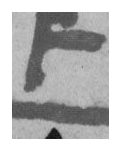

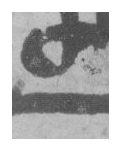

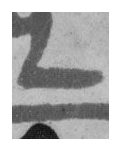

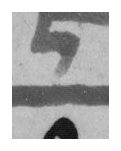

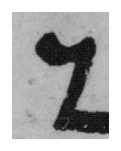

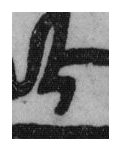

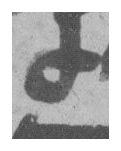

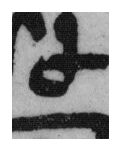

2) Same page as the four dropped stamps, but a bigger block


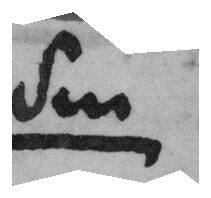

In [1]:
def show_crop_only(image_name: str, problem: str) -> None:
    """Show crop + GT only. No Calamari call — the issue is the pixels vs the label."""
    split, gt, path = lookup_gt(image_name)
    with PILImage.open(path) as image:
        width, height = image.size
    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(image_name)}</b> &nbsp; split=<code>{split}</code>"
            f" &nbsp; crop={width}×{height} px</p>"
            f"<p style='color:#a33'><b>Problem.</b> {escape(problem)}</p>"
        )
    )
    display(IPyImage(filename=str(path)))
    display(
        HTML(
            "<pre style='white-space:pre-wrap;font-size:14px'>"
            f"GT:   {escape(gt)}\n"
            "pixels also contain a horizontal bar at the bottom that is not in GT"
            "</pre>"
        )
    )


print("1) Same 121×151 gutter rectangle, still in the corpus")
for name, note in (
    ("ms_ucla_ms__0010__048.jpg", "Finetune test. GT բ. 121×151 stamp; letter plus the line under it."),
    ("ms_ucla_ms__0009__062.jpg", "Finetune train. GT ժզ. Same 121×151 box; bar across the bottom."),
    ("ms_ucla_ms__0012__048.jpg", "Finetune train. GT զ. Same stamp as the dropped գ/դ/մ boxes."),
    ("ms_ucla_ms__0012__049.jpg", "Finetune train. GT է. Same box; bar is most of the crop."),
    ("ms_ucla_ms__0013__047.jpg", "Finetune train. GT զ. Same 121×151 rectangle on page 0013."),
    ("ms_ucla_ms__0014__047.jpg", "Finetune train. GT մէ. Same box; two letters plus the underline."),
    ("ms_ucla_ms__0016__047.jpg", "Pretrain test. GT ժդ. Same 121×151 stamp."),
    ("ms_ucla_ms__0016__048.jpg", "Pretrain test. GT մժ. Same 121×151 stamp."),
):
    show_crop_only(name, note)

print("2) Same page as the four dropped stamps, but a bigger block")
show_crop_only(
    "ms_ucla_ms__0011__045.jpg",
    "Pretrain val. GT մա. Not the 121×151 gutter stamp: 211×198. "
    "մ and ա are visible, but the crop is a square and the thick bar under the letters is in the image, not in GT.",
)


## 14. Dulaurier `~` (Calfa ideogram for աշխարհ)

Six lines still have ASCII `~` in the GT. Calfa used that character for a **printed world-ideogram**, not for the letters աշխարհ.

Look at the crop: is the ink a wavy special glyph (then `~` is a stand-in, and spelling աշխարհ would put letters that are not drawn), or is it abbreviated letters with a bar (then GT should be those letters + `՟`)? Do not change the labels until that is decided. The next cell shows all six, full line plus a zoom on the mark.


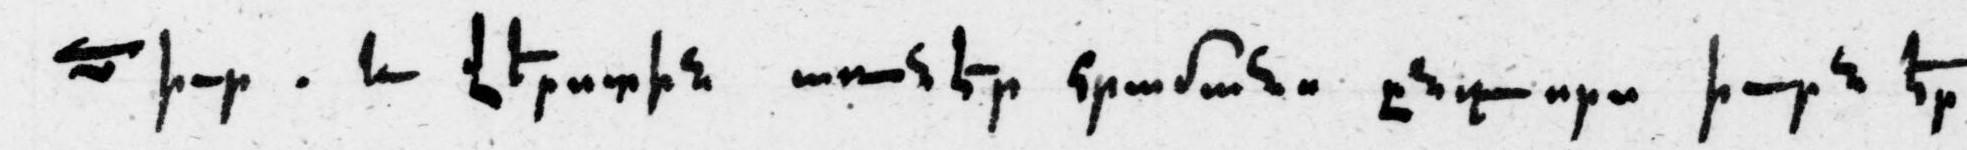

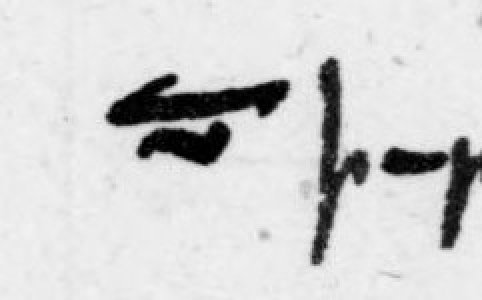

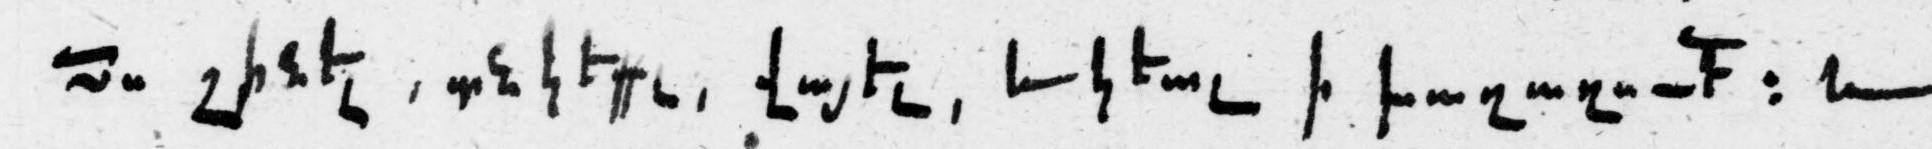

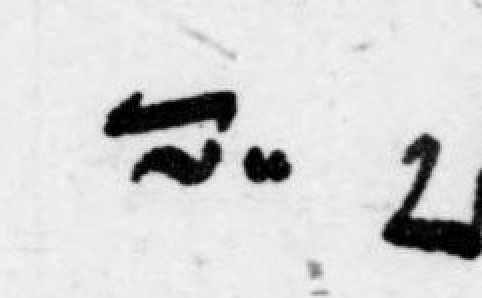

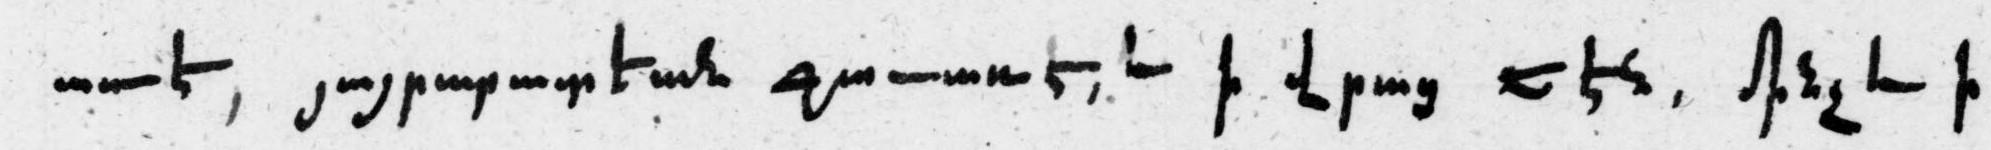

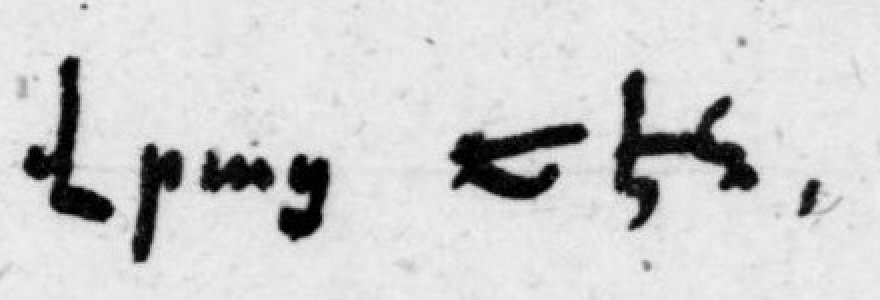

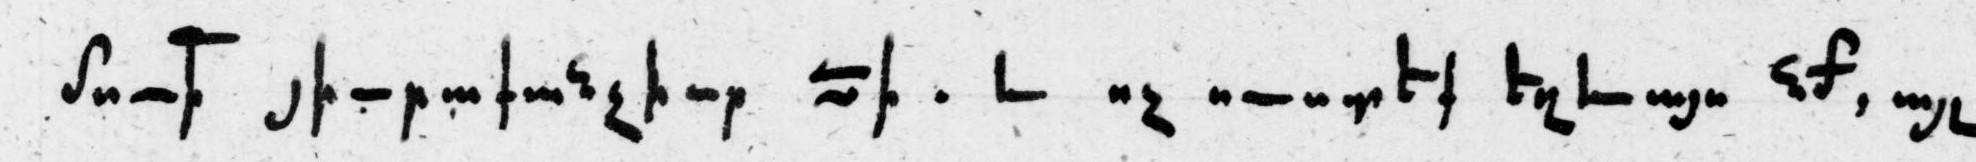

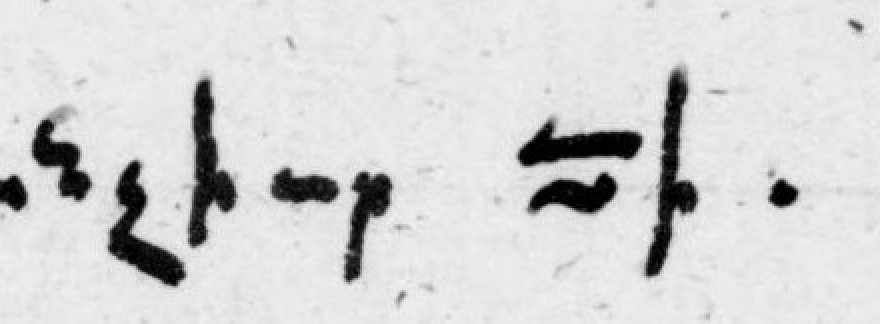

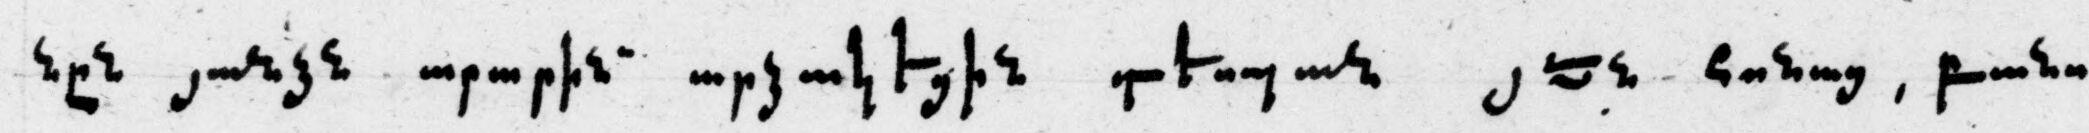

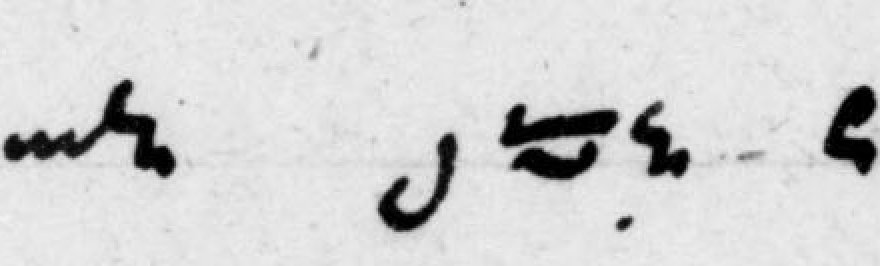

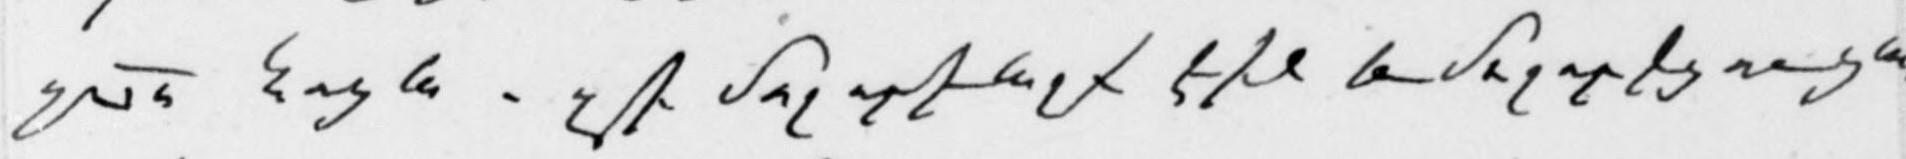

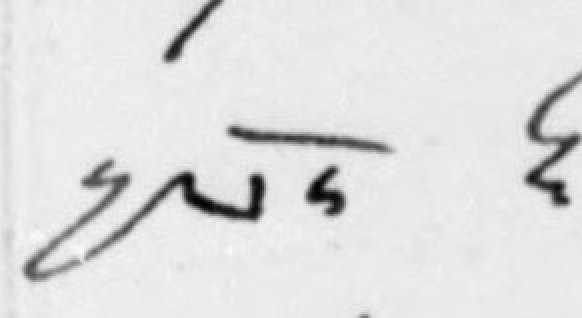

In [1]:
from PIL import ImageDraw


def show_tilde_line(image_name: str) -> None:
    split, gt, path = lookup_gt(image_name)
    with PILImage.open(path) as image:
        width, height = image.size
        rgb = image.convert("RGB")
    index = gt.find("~")
    # zoom a window around the ~ in the string, mapped onto image width
    frac = (index + 0.5) / max(len(gt), 1)
    center = int(frac * width)
    pad = 220
    x0 = max(0, center - pad)
    x1 = min(width, center + pad)
    zoom = rgb.crop((x0, 0, x1, height)).resize(
        ((x1 - x0) * 2, height * 2),
        PILImage.Resampling.NEAREST,
    )
    marked = gt.replace("~", "⟦~⟧")
    display(
        HTML(
            "<hr>"
            f"<p><b>{escape(image_name)}</b> &nbsp; split=<code>{split}</code>"
            f" &nbsp; crop={width}×{height} px</p>"
            "<pre style='white-space:pre-wrap;font-size:14px'>"
            f"GT: {escape(marked)}"
            "</pre>"
            "<p>Full line, then a 2× zoom around where <code>~</code> sits in the GT:</p>"
        )
    )
    display(IPyImage(filename=str(path)))
    display(zoom)


for name in (
    "armenian_datalab_dulaurier_0000678.jpg",
    "armenian_datalab_dulaurier_0000679.jpg",
    "armenian_datalab_dulaurier_0000686.jpg",
    "armenian_datalab_dulaurier_0000690.jpg",
    "armenian_datalab_dulaurier_0000845.jpg",
    "armenian_datalab_dulaurier_0001227.jpg",
):
    show_tilde_line(name)
